In [18]:
from __future__ import annotations
import io
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    adjusted_rand_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    silhouette_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")



In [19]:
#determining Random seed and test fraction
_rs = input("Random seed number [42]: ").strip()
RANDOM_STATE = int(_rs) if _rs else 42

_ts = input("How much data for testing (0.2 means 20 percent) [0.2]: ").strip()
TEST_SIZE = float(_ts) if _ts else 0.2
TEST_SIZE = max(0.05, min(0.45, TEST_SIZE))

np.random.seed(RANDOM_STATE)
print("Saved settings: seed=", RANDOM_STATE, " test fraction=", TEST_SIZE)

Random seed number [42]: 55
How much data for testing (0.2 means 20 percent) [0.2]: 0.3
Saved settings: seed= 55  test fraction= 0.3


In [20]:
# Data loading

if "RANDOM_STATE" not in globals():
    RANDOM_STATE = 42
if "TEST_SIZE" not in globals():
    TEST_SIZE = 0.2
np.random.seed(RANDOM_STATE)

COLUMN_ALIASES = {

    "age_months": ["age_months", "age", "b19", "hw1"],
    "sex": ["sex", "b4", "gender"],
    "weight_kg": ["weight_kg", "hw2", "weight"],
    "height_cm": ["height_cm", "hw3", "height"],
    "muac_cm": ["muac_cm", "muac", "hw54"],
    "haz": ["haz", "hw70", "HAZ"],
    "waz": ["waz", "hw71", "WAZ"],
    "whz": ["whz", "hw72", "WHZ"],
    "nutrition_status": ["nutrition_status", "label", "target", "nutri"],
}


def _pick_column(df: pd.DataFrame, candidates: list[str]) -> str | None:
    """Return the first column name in `df` that matches one of the aliases (case-insensitive)."""
    lower = {c.lower(): c for c in df.columns}
    for name in candidates:
        if name in df.columns:
            return name
        if name.lower() in lower:
            return lower[name.lower()]
    return None


def _normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Rename known alias columns to canonical names (e.g. hw70 -> haz)."""
    rename: dict[str, str] = {}
    for canon, alts in COLUMN_ALIASES.items():
        hit = _pick_column(df, alts)
        if hit and hit != canon:
            rename[hit] = canon
    return df.rename(columns=rename)


def _read_csv_from_path(path: Path) -> pd.DataFrame:
    return _normalize_columns(pd.read_csv(path))


def _load_from_colab_upload() -> tuple[list[pd.DataFrame], list[str]]:
    """Google Colab only: upload files in browser; returns frames + filenames."""
    from google.colab import files

    print("colab: hit Choose Files and pick your csv")
    uploaded = files.upload()
    frames: list[pd.DataFrame] = []
    names: list[str] = []
    for filename, content in uploaded.items():
        if not filename.lower().endswith(".csv"):
            print(f"  Skipping non-CSV: {filename}")
            continue
        frames.append(_normalize_columns(pd.read_csv(io.BytesIO(content))))
        names.append(filename)
    return frames, names


def _load_from_local_file_dialog() -> tuple[list[pd.DataFrame], list[str]]:
    """Local Jupyter: OS file picker — multi-select supported."""
    import tkinter as tk
    from tkinter import filedialog

    root = tk.Tk()
    root.withdraw()
    root.attributes("-topmost", True)
    paths = filedialog.askopenfilenames(
        title="Select one or more CSV files (Ctrl+click or Shift for multiple)",
        filetypes=[("CSV files", "*.csv"), ("All files", "*.*")],
    )
    root.destroy()

    frames: list[pd.DataFrame] = []
    names: list[str] = []
    for p in paths:
        pp = Path(p)
        frames.append(_read_csv_from_path(pp))
        names.append(pp.name)
    return frames, names


def load_many_csvs_interactive() -> tuple[pd.DataFrame, list[str]]:
    frames: list[pd.DataFrame] = []
    sources: list[str] = []

    try:
        frames, sources = _load_from_colab_upload()
    except ImportError:
        try:
            frames, sources = _load_from_local_file_dialog()
        except Exception as exc:
            print(f"File dialog failed ({exc}).")


    combined = pd.concat(frames, axis=0, ignore_index=True)
    print(f"Loaded {len(sources)} file(s): {sources} → total rows: {len(combined)}")
    return combined, sources


# Output folders for figures and metrics tables
FIG_DIR = Path("figures")
RESULTS_DIR = Path("results")
for d in (FIG_DIR, RESULTS_DIR):
    d.mkdir(exist_ok=True)


raw, _csv_sources = load_many_csvs_interactive()

print("Shape:", raw.shape)
display(raw.head())

colab: hit Choose Files and pick your csv


Saving child_nutrition_dataset.csv to child_nutrition_dataset (1).csv
Loaded 1 file(s): ['child_nutrition_dataset (1).csv'] → total rows: 3000
Shape: (3000, 6)


,age_months,sex,haz,waz,whz,muac_cm
0,18,0,0.195,-0.283,0.480,14.20
1,43,0,-2.110,-2.171,-2.028,13.16
2,49,0,-2.532,-2.162,-2.524,13.20
3,9,1,-2.770,-2.990,-2.686,12.96
4,16,1,1.194,0.955,0.141,12.92


In [21]:
def derive_labels_from_zscores(row: pd.Series) -> int:

    zs = [row["haz"], row["waz"], row["whz"]]
    m = min(zs)
    if m < -3:
        return 2
    if m < -2:
        return 1
    return 0


#Build modelling table: required columns, optional labels, drop incomplete rows
df = raw.copy()
needed_z = ["haz", "waz", "whz"]
for z in needed_z:
    if z not in df.columns:
        raise ValueError(f"Missing column {z}. Compute Z-scores from WHO LMS or add columns to CSV.")


if "nutrition_status" not in df.columns:
    df["nutrition_status"] = df.apply(derive_labels_from_zscores, axis=1)


feature_cols = ["haz", "waz", "whz", "muac_cm", "age_months", "sex"]
missing = [c for c in feature_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing features: {missing}")

df = df.dropna(subset=feature_cols + ["nutrition_status"])

X = df[feature_cols].values
y = df["nutrition_status"].astype(int).values
print("Class counts:", dict(zip(*np.unique(y, return_counts=True))))

Class counts: {np.int64(0): np.int64(1740), np.int64(1): np.int64(897), np.int64(2): np.int64(363)}


Saved figures/fig1_system_pipeline.png


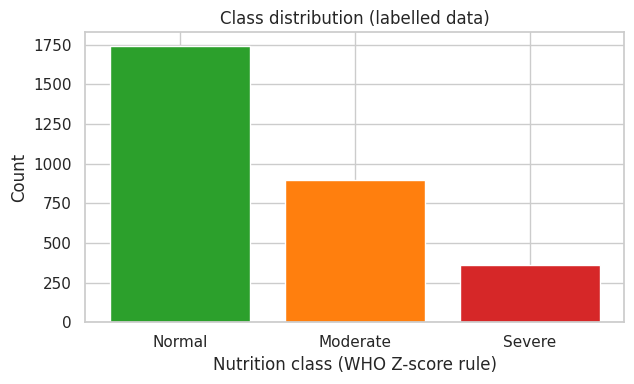

Saved figures/fig2_class_distribution.png


In [22]:
#class distribution
CLASS_NAMES_LBL = ["Normal", "Moderate", "Severe"]


def save_fig1_system_pipeline(out_dir: Path) -> None:
    """Schematic: raw features → preprocess → supervised + unsupervised models → metrics/exports."""
    fig, ax = plt.subplots(figsize=(9, 2.4))
    ax.axis("off")
    boxes = [
        (0.02, 0.18, 0.15, 0.64, "Data\n(HAZ, WAZ,\nWHZ, MUAC,\nage, sex)"),
        (0.21, 0.18, 0.17, 0.64, "Preprocess\nscale; SMOTE\n(train only)"),
        (0.42, 0.18, 0.13, 0.64, "RF\n+ LR"),
        (0.58, 0.18, 0.13, 0.64, "K-Means\n(k vs inertia)"),
        (0.75, 0.18, 0.13, 0.64, "Metrics\n& exports"),
    ]
    for x, y, w, h, t in boxes:
        ax.add_patch(plt.Rectangle((x, y), w, h, fill=False, ec="k", lw=1.2))
        ax.text(x + w / 2, y + h / 2, t, ha="center", va="center", fontsize=9)
    for x0, x1 in [(0.17, 0.21), (0.38, 0.42), (0.55, 0.58), (0.71, 0.75)]:
        ax.annotate("", xy=(x1, 0.5), xytext=(x0, 0.5), arrowprops=dict(arrowstyle="->", lw=1.2))
    fig.suptitle("System pipeline (schematic)", y=0.95, fontsize=11)
    p = out_dir / "fig1_system_pipeline.png"
    fig.savefig(p, dpi=200, bbox_inches="tight")
    plt.close(fig)
    print("Saved", p)


save_fig1_system_pipeline(FIG_DIR)

#class frequency bar chart
fig, ax = plt.subplots(figsize=(6.5, 4))
vc = df["nutrition_status"].value_counts().reindex([0, 1, 2], fill_value=0)
ax.bar([CLASS_NAMES_LBL[i] for i in vc.index], vc.values, color=["#2ca02c", "#ff7f0e", "#d62728"])
ax.set_ylabel("Count")
ax.set_xlabel("Nutrition class (WHO Z-score rule)")
ax.set_title("Class distribution (labelled data)")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig2_class_distribution.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved", FIG_DIR / "fig2_class_distribution.png")

In [23]:
#Preprocessing / split / SMOTE

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

#  Standardize numeric features using TRAIN statistics only.
#    This prevents data leakage from test
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Balance only the training set with SMOTE.
smote = SMOTE(random_state=RANDOM_STATE)
X_tr_bal, y_tr_bal = smote.fit_resample(X_train_s, y_train)
print("After SMOTE (train):", dict(zip(*np.unique(y_tr_bal, return_counts=True))))

After SMOTE (train): {np.int64(0): np.int64(1218), np.int64(1): np.int64(1218), np.int64(2): np.int64(1218)}


In [24]:
#Random Forest + Logistic Regression training


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rf_grid = {
    "n_estimators": [100, 200],
    "max_depth": [8, 12, None],
    "min_samples_split": [2, 5],
}
rf = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    rf_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
)
rf.fit(X_tr_bal, y_tr_bal)
print("Best RF:", rf.best_params_)

# Logistic Regression
lr_pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "lr",
            LogisticRegression(
                max_iter=2000,
                solver="lbfgs",
                C=1.0,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
lr_pipe.fit(X_tr_bal, y_tr_bal)

# Evaluate both models
y_pred_rf = rf.predict(X_test_s)
y_pred_lr = lr_pipe.predict(X_test_s)

for name, yp in [("Random Forest", y_pred_rf), ("Logistic Regression", y_pred_lr)]:
    print(f"\n=== {name} ===")
    print(f"Accuracy: {accuracy_score(y_test, yp):.4f}")
    print(f"Macro F1: {f1_score(y_test, yp, average='macro'):.4f}")
    print(classification_report(y_test, yp, target_names=["Normal", "Moderate", "Severe"]))

Best RF: {'max_depth': 8, 'min_samples_split': 2, 'n_estimators': 200}

=== Random Forest ===
Accuracy: 0.9967
Macro F1: 0.9972
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00       522
    Moderate       0.99      1.00      0.99       269
      Severe       1.00      1.00      1.00       109

    accuracy                           1.00       900
   macro avg       1.00      1.00      1.00       900
weighted avg       1.00      1.00      1.00       900


=== Logistic Regression ===
Accuracy: 0.9967
Macro F1: 0.9972
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00       522
    Moderate       0.99      1.00      0.99       269
      Severe       1.00      1.00      1.00       109

    accuracy                           1.00       900
   macro avg       1.00      1.00      1.00       900
weighted avg       1.00      1.00      1.00       900



In [25]:
#test confusion matrices
tick_lbls = ["Normal", "Moderate", "Severe"]
for name, yp, fname in [
    ("Random Forest", y_pred_rf, "fig3_rf_confusion_matrix.png"),
    ("Logistic Regression", y_pred_lr, "fig4_lr_confusion_matrix.png"),
]:
    fig, ax = plt.subplots(figsize=(4.6, 4.2))
    ConfusionMatrixDisplay.from_predictions(
        y_test, yp, display_labels=tick_lbls, ax=ax, cmap="Blues", colorbar=False
    )
    ax.set_title(f"{name} (test set)")
    fig.tight_layout()
    fig.savefig(FIG_DIR / fname, dpi=200, bbox_inches="tight")
    plt.close(fig)
    print("Saved", FIG_DIR / fname)

Saved figures/fig3_rf_confusion_matrix.png
Saved figures/fig4_lr_confusion_matrix.png


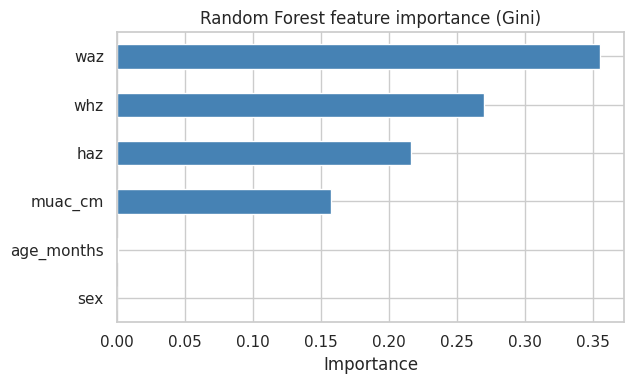

Saved figures/fig6_feature_importance.png
Saved results/Table3_Random_Forest_feature_importance.csv


In [26]:
# Random Forest feature importances (horizontal bars) + Table 3 CSV
imp = pd.Series(rf.best_estimator_.feature_importances_, index=feature_cols).sort_values()
fig, ax = plt.subplots(figsize=(6.5, 4))
imp.plot.barh(ax=ax, color="steelblue")
ax.set_title("Random Forest feature importance (Gini)")
ax.set_xlabel("Importance")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig6_feature_importance.png", dpi=200, bbox_inches="tight")
plt.show()

imp.sort_values(ascending=False).to_frame("importance").to_csv(
    RESULTS_DIR / "Table3_Random_Forest_feature_importance.csv", index=True
)
print("Saved", FIG_DIR / "fig6_feature_importance.png")
print("Saved", RESULTS_DIR / "Table3_Random_Forest_feature_importance.csv")

In [27]:
#  hold out test metrics


def collect_metrics(name: str, y_true, y_pred, y_proba) -> dict:
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "roc_auc_ovr": roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro"),
    }


y_proba_rf = rf.predict_proba(X_test_s)
y_proba_lr = lr_pipe.predict_proba(X_test_s)
metrics_table = pd.DataFrame(
    [
        collect_metrics("Random Forest", y_test, y_pred_rf, y_proba_rf),
        collect_metrics("Logistic Regression", y_test, y_pred_lr, y_proba_lr),
    ]
)
print("Test-set summary (macro-averaged) — Table 2:")
display(metrics_table)
out_metrics = RESULTS_DIR / "Table2_Classification_metrics_test_set.csv"
metrics_table.to_csv(out_metrics, index=False)
print("Saved:", out_metrics.resolve())

# Quick sanity check on a few test rows
preview_n = min(8, len(X_test))
sample_idx = np.arange(preview_n)
preview_df = pd.DataFrame(
    {
        "true_label": [CLASS_NAMES_LBL[i] for i in y_test[sample_idx]],
        "pred_RF": [CLASS_NAMES_LBL[i] for i in y_pred_rf[sample_idx]],
        "pred_LR": [CLASS_NAMES_LBL[i] for i in y_pred_lr[sample_idx]],
    }
)
print("Sample test rows (first few):")
display(preview_df)

Test-set summary (macro-averaged) — Table 2:


,model,accuracy,precision_macro,recall_macro,f1_macro,roc_auc_ovr
0,Random Forest,0.996667,0.996324,0.998084,0.997191,1.00000
1,Logistic Regression,0.996667,0.996324,0.998084,0.997191,0.99997


Saved: /content/results/Table2_Classification_metrics_test_set.csv
Sample test rows (first few):


,true_label,pred_RF,pred_LR
0,Moderate,Moderate,Moderate
1,Normal,Normal,Normal
2,Normal,Normal,Normal
3,Normal,Normal,Normal
4,Normal,Normal,Normal
5,Normal,Normal,Normal
6,Normal,Normal,Normal
7,Severe,Severe,Severe


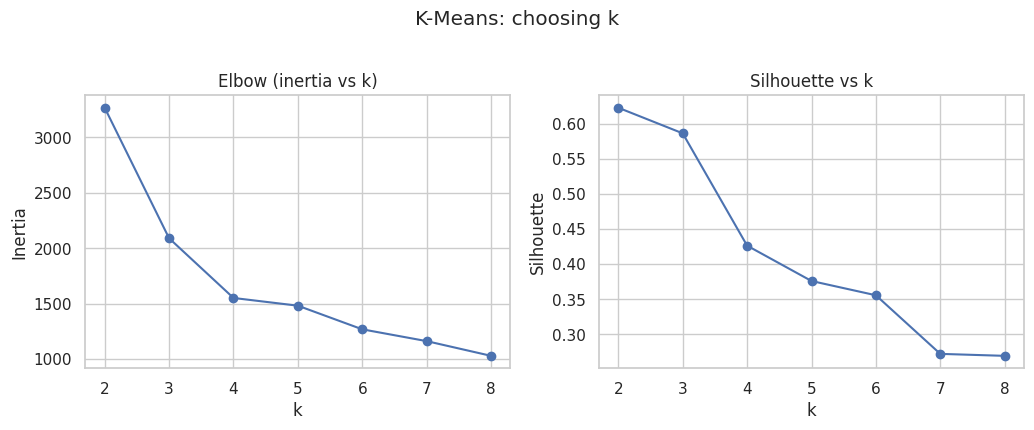

Saved figures/fig5_elbow_silhouette.png
Silhouette (k=3): 0.5862170594392305
ARI vs nutrition_status: 0.9658976476389245
Saved results/Table_KMeans_summary_k3.csv


In [28]:
# K-Means diagnostics — elbow + silhouette vs k (k = 2..8), then evaluate k=3

km_feats = StandardScaler().fit_transform(df[["haz", "waz", "whz", "muac_cm"]].values)

inertias, silhouettes = [], []
ks = range(2, 9)
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
    lab = km.fit_predict(km_feats)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(km_feats, lab))

# Plot both diagnostics side by side as report figure fig5.
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
axes[0].plot(list(ks), inertias, marker="o")
axes[0].set_title("Elbow (inertia vs k)")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[1].plot(list(ks), silhouettes, marker="o")
axes[1].set_title("Silhouette vs k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette")
fig.suptitle("K-Means: choosing k", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig5_elbow_silhouette.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved", FIG_DIR / "fig5_elbow_silhouette.png")


km3 = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init="auto")
cluster_labels = km3.fit_predict(km_feats)
sil_k3 = silhouette_score(km_feats, cluster_labels)
ari = adjusted_rand_score(y, cluster_labels)
print("Silhouette (k=3):", sil_k3)
print("ARI vs nutrition_status:", ari)

pd.DataFrame([{"k": 3, "silhouette": sil_k3, "ari_vs_labels": ari}]).to_csv(
    RESULTS_DIR / "Table_KMeans_summary_k3.csv", index=False
)
print("Saved", RESULTS_DIR / "Table_KMeans_summary_k3.csv")

In [29]:
# Persist trained objects for reuse
artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(exist_ok=True)
joblib.dump(rf.best_estimator_, artifacts_dir / "random_forest.joblib")
joblib.dump(lr_pipe, artifacts_dir / "logistic_regression_pipeline.joblib")
joblib.dump(scaler, artifacts_dir / "feature_scaler.joblib")
print("Saved:", list(artifacts_dir.glob("*.joblib")))

Saved: [PosixPath('artifacts/random_forest.joblib'), PosixPath('artifacts/feature_scaler.joblib'), PosixPath('artifacts/logistic_regression_pipeline.joblib')]


In [30]:

LABEL_EN = {
    0: "Normal (adequate nutrition)",
    1: "Moderately malnourished",
    2: "Severely malnourished",
}


def _who_z_label(haz: float, waz: float, whz: float) -> int:
    m = min(haz, waz, whz)
    if m < -3:
        return 2
    if m < -2:
        return 1
    return 0


print("\n--- try one kid (optional, after training) ---")
_ans = input("run it? y/n [y]: ").strip().lower() or "y"

if _ans not in ("y", "yes", ""):
    print("skipped")
else:
    try:
        _h = input("haz [0]: ").strip()
        haz = float(_h) if _h else 0.0
        _w = input("waz [0]: ").strip()
        waz = float(_w) if _w else 0.0
        _z = input("whz [0]: ").strip()
        whz = float(_z) if _z else 0.0
        _m = input("muac cm [13.5]: ").strip()
        muac = float(_m) if _m else 13.5
        _a = input("age months [24]: ").strip()
        age_m = int(float(_a)) if _a else 24
        _s = input("sex 0/1 [0]: ").strip()
        sex = int(_s) if _s else 0
    except ValueError as err:
        print("bad input", err)
    else:
        X_one = np.array([[haz, waz, whz, muac, age_m, sex]], dtype=float)
        Xs = scaler.transform(X_one)
        pr_rf = int(rf.predict(Xs)[0])
        pr_lr = int(lr_pipe.predict(Xs)[0])
        who = _who_z_label(haz, waz, whz)
        p_rf = rf.predict_proba(Xs)[0]

        print("\nwho rule:", LABEL_EN[who])
        print("rf:", LABEL_EN[pr_rf])
        print("lr:", LABEL_EN[pr_lr])
        print("rf probs norm/mod/sev:", round(p_rf[0], 2), round(p_rf[1], 2), round(p_rf[2], 2))
        if pr_rf == 0:
            print("-> rf says normal")
        else:
            print("-> rf says malnutrition:", "moderate" if pr_rf == 1 else "severe")
        if who == 0 and pr_rf == 0:
            print("(who + rf agree normal)")


--- try one kid (optional, after training) ---
run it? y/n [y]: y
haz [0]: 0.2
waz [0]: -0.4
whz [0]: -0.6
muac cm [13.5]: 15
age months [24]: 15
sex 0/1 [0]: 1

who rule: Normal (adequate nutrition)
rf: Normal (adequate nutrition)
lr: Normal (adequate nutrition)
rf probs norm/mod/sev: 1.0 0.0 0.0
-> rf says normal
(who + rf agree normal)
